In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


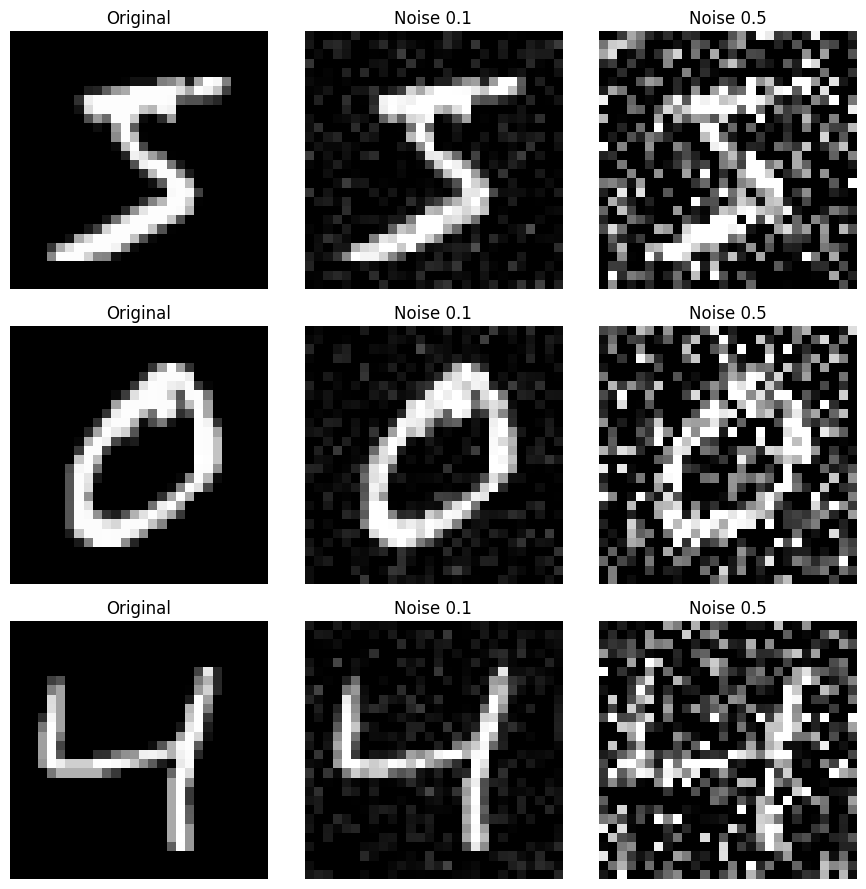

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
import os
import random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
# Load and preprocess MNIST
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))
#Generate noisy versions
noise_factor_low = 0.1
noise_factor_high = 0.5
x_train_noisy_low = x_train + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_train_noisy_high = x_train + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy_low = x_test + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
x_test_noisy_high = x_test + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
# Clip pixel values to [0, 1]
x_train_noisy_low = np.clip(x_train_noisy_low, 0., 1.)
x_test_noisy_low = np.clip(x_test_noisy_low, 0., 1.)
x_train_noisy_high = np.clip(x_train_noisy_high, 0., 1.)
x_test_noisy_high = np.clip(x_test_noisy_high, 0., 1.)
#Visualize in a 3 x 3 grid
n = 3 # number of images to show
plt.figure(figsize=(9, 9))
for i in range(n):
# Original image
    ax = plt.subplot(n, 3, i * 3 + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')
# Low noise image
    ax = plt.subplot(n, 3, i * 3 + 2)
    plt.imshow(x_train_noisy_low[i].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.1")
    plt.axis('off')
# High noise image
    ax = plt.subplot(n, 3, i * 3 + 3)
    plt.imshow(x_train_noisy_high[i].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.5")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [3]:
def build_encoder(input_shape=(28, 28, 1)):

  """Builds the encoder part of the convolutional autoencoder.
  Parameters:
  input_shape (tuple): Shape of the input image. Default is (28, 28, 1) for MNIST.
  Returns:
  input_img (Keras Input): Input layer of the model.
  encoded (Keras Tensor): Encoded representation after convolution and pooling.
"""
  input_img = Input(shape=input_shape, name="input")
  x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
  x = MaxPooling2D((2, 2), padding='same')(x)
  x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
  encoded = MaxPooling2D((2, 2), padding='same', name="encoded")(x)
  return input_img, encoded

In [4]:
def build_decoder(encoded_input):
  """
  Builds the decoder part of the convolutional autoencoder.
  Parameters:
  encoded_input (Keras Tensor): The output from the encoder.
  Returns:
  decoded (Keras Tensor): The reconstructed output after upsampling and
  convolution.
  """
  x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(encoded_input)
  x = layers.UpSampling2D((2, 2))(x)
  x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
  x = layers.UpSampling2D((2, 2))(x)
  decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoded")(x)
  return decoded

In [5]:
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D

def build_autoencoder():
  """
  Constructs and compiles the full convolutional autoencoder by connecting encoder and
  decoder.
  Returns:
  autoencoder (Keras Model): Compiled autoencoder model.
  """
  input_img, encoded_output = build_encoder()
  decoded_output = build_decoder(encoded_output)
  autoencoder = Model(inputs=input_img, outputs=decoded_output, name="autoencoder")
  autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')
  return autoencoder

In [6]:
autoencoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Build the autoencoder from previous steps
autoencoder = build_autoencoder()
# Train with noisy input and clean target
history = autoencoder.fit(
    x_train_noisy_high, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy_high, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 0.1489 - val_loss: 0.1117
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1089 - val_loss: 0.1043
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.1039 - val_loss: 0.1013
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1015 - val_loss: 0.0998
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0999 - val_loss: 0.0985
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0988 - val_loss: 0.0975
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0980 - val_loss: 0.0967
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0971 - val_loss: 0.0966
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0965 - val_loss: 0.0957
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0960 - val_loss: 0.0953


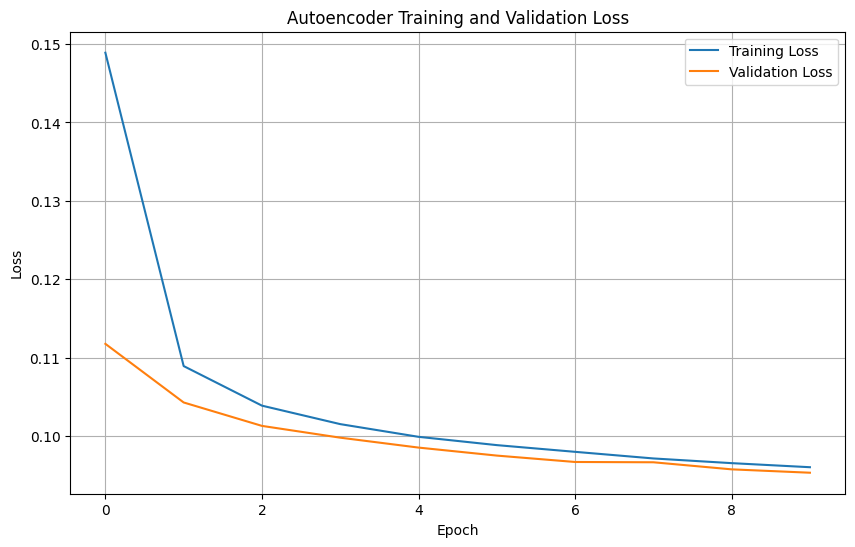

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Autoencoder Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


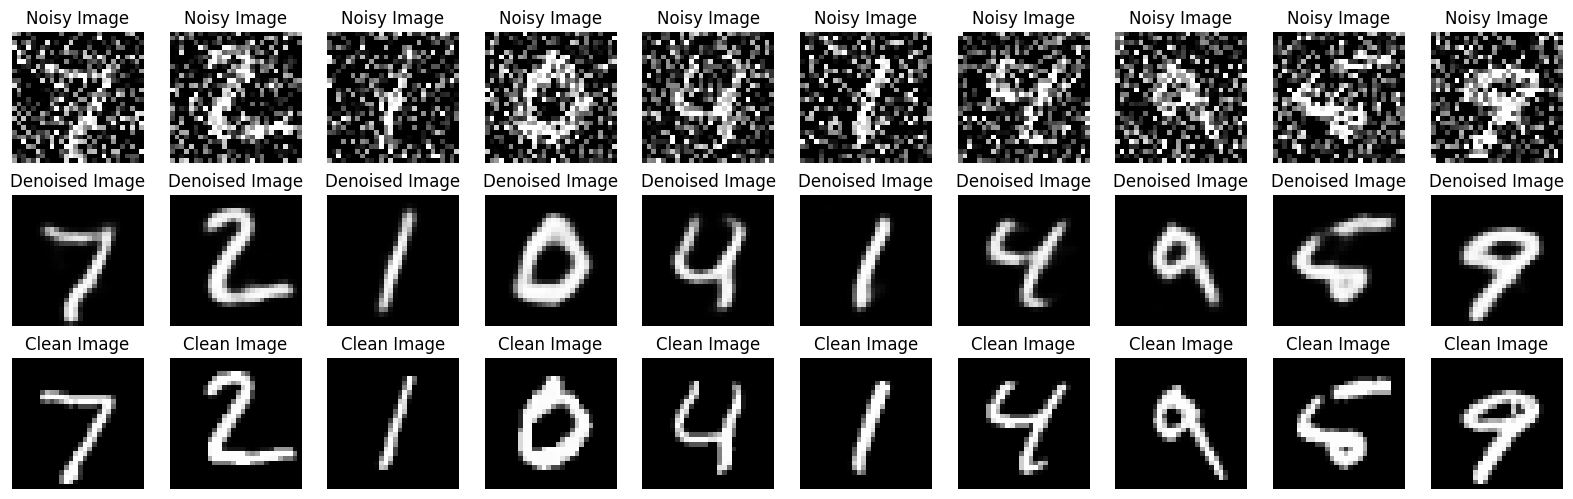

In [9]:
denoised_images = autoencoder.predict(x_test_noisy_high)

def plot_images(noisy_images, denoised_images, clean_images, n=10):
  plt.figure(figsize=(20, 6))
  for i in range(n):
    # Plot noisy images
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(noisy_images[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy Image")
    plt.axis('off')

    # Plot denoised images
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
    plt.title("Denoised Image")
    plt.axis('off')

    # Plot clean images
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(clean_images[i].reshape(28, 28), cmap='gray')
    plt.title("Clean Image")
    plt.axis('off')
  plt.show()

plot_images(x_test_noisy_high, denoised_images, x_test, n=10)

## 4.1 Devnagari Denoising Autoencoder Implementation

In [11]:
!cp -r "/content/drive/MyDrive/AI_and_ML/Week 4 - Multi Layer Neural Network/DevanagariHandwrittenDigitDataset" /content/

Loading images from: /content/DevanagariHandwrittenDigitDataset/Train
Loading images from: /content/DevanagariHandwrittenDigitDataset/Test
Error loading image /content/DevanagariHandwrittenDigitDataset/Test/digit_7/91640.png: cannot identify image file '/content/DevanagariHandwrittenDigitDataset/Test/digit_7/91640.png'
Error loading image /content/DevanagariHandwrittenDigitDataset/Test/digit_7/68093.png: cannot identify image file '/content/DevanagariHandwrittenDigitDataset/Test/digit_7/68093.png'
Error loading image /content/DevanagariHandwrittenDigitDataset/Test/digit_7/56650.png: cannot identify image file '/content/DevanagariHandwrittenDigitDataset/Test/digit_7/56650.png'
Error loading image /content/DevanagariHandwrittenDigitDataset/Test/digit_7/78479.png: cannot identify image file '/content/DevanagariHandwrittenDigitDataset/Test/digit_7/78479.png'
Error loading image /content/DevanagariHandwrittenDigitDataset/Test/digit_7/41915.png: cannot identify image file '/content/Devanagar

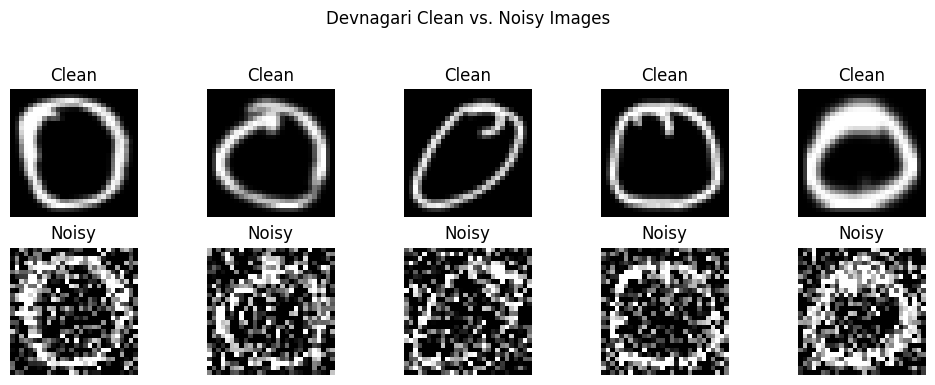

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D

# --- 1. Dataset Preparation and Preprocessing ---

# Define dataset paths from Google Drive
train_dir = "/content/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/DevanagariHandwrittenDigitDataset/Test"

image_size = (28, 28)

def load_images_from_directory(directory):
    images = []
    labels = []
    if not os.path.exists(directory):
        print(f"Error: Directory not found: {directory}")
        return None, None

    all_classes = sorted([d for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d))])

    if not all_classes:
        print(f"No character class directories found in {directory}. Check dataset structure.")
        return None, None

    print(f"Loading images from: {directory}")
    for i, class_name in enumerate(all_classes):
        class_path = os.path.join(directory, class_name)
        for image_file in os.listdir(class_path):
            if image_file.endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(class_path, image_file)
                try:
                    img = Image.open(img_path).convert('L') # Convert to grayscale
                    img = img.resize(image_size) # Resize to 28x28
                    img_array = np.array(img)
                    images.append(img_array)
                    labels.append(i)
                except Exception as e:
                    print(f"Error loading image {img_path}: {e}")

    if images:
        x = np.array(images).astype('float32') / 255. # Normalize to [0, 1]
        x = np.reshape(x, (len(x), image_size[0], image_size[1], 1)) # Reshape for Keras compatibility
        return x, labels
    else:
        print(f"No images were loaded from {directory}.")
        return None, None


x_train_dev, y_train_dev = load_images_from_directory(train_dir)
x_test_dev, y_test_dev = load_images_from_directory(test_dir)

if x_train_dev is not None and x_test_dev is not None:
    print(f"Loaded {len(x_train_dev)} Devnagari training images and {len(x_test_dev)} Devnagari test images.")

    # Add noise to the images
    noise_factor = 0.5 # Using a single noise factor for simplicity as requested by problem description
    x_train_noisy_dev = x_train_dev + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train_dev.shape)
    x_test_noisy_dev = x_test_dev + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test_dev.shape)

    # Clip pixel values to [0, 1]
    x_train_noisy_dev = np.clip(x_train_noisy_dev, 0., 1.)
    x_test_noisy_dev = np.clip(x_test_noisy_dev, 0., 1.)

    # Visualize a few noisy and clean images
    n = 5 # number of images to show
    plt.figure(figsize=(10, 4))
    for i in range(n):
        # Original image
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(x_train_dev[i].reshape(image_size), cmap='gray')
        plt.title("Clean")
        plt.axis('off')

        # Noisy image
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(x_train_noisy_dev[i].reshape(image_size), cmap='gray')
        plt.title("Noisy")
        plt.axis('off')
    plt.suptitle("Devnagari Clean vs. Noisy Images")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()
else:
    print("Skipping Devnagari image loading and processing due to missing data.")


### 2. Build the Denoising Convolutional Autoencoder for Devnagari

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
import matplotlib.pyplot as plt

# Redefine the encoder with corrected architecture to produce 7x7 output
def build_devnagari_encoder(input_shape=(28, 28, 1)):
  input_img = Input(shape=input_shape, name="dev_input")
  x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
  x = MaxPooling2D((2, 2), padding='same')(x)
  x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
  # Adding another Conv2D layer and then a MaxPooling2D to get to 7x7
  x = Conv2D(128, (3, 3), activation='relu', padding='same')(x) # 14x14x128
  encoded = MaxPooling2D((2, 2), padding='same', name="dev_encoded_final")(x) # Output will be 7x7x128
  return input_img, encoded

# Redefine the decoder with corrected architecture to accept 7x7 input and produce 28x28 output
def build_devnagari_decoder(encoded_input):
  x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(encoded_input) # 7x7x128
  x = layers.UpSampling2D((2, 2))(x) # 14x14x128
  x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x) # 14x14x64
  x = layers.UpSampling2D((2, 2))(x) # 28x28x64
  x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x) # 28x28x32
  decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="dev_decoded")(x) # 28x28x1
  return decoded

# Redefine the autoencoder builder to use the corrected encoder and decoder
def build_devnagari_autoencoder():
  input_img, encoded_output = build_devnagari_encoder()
  decoded_output = build_devnagari_decoder(encoded_output)
  autoencoder = Model(inputs=input_img, outputs=decoded_output, name="devnagari_autoencoder")
  autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')
  return autoencoder

### 3. Train the Denoising Autoencoder for Devnagari

Model: "devnagari_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dev_input (InputLayer)          │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dev_encoded_final               │ (None, 7, 7, 128)      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_7 (UpSampling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 14, 14, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_8 (UpSampling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 28, 28, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dev_decoded (Conv2D)            │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 332,801 (1.27 MB)

 Trainable params: 332,801 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step - loss: 0.2861 - val_loss: 0.2107
Epoch 2/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.1969 - val_loss: 0.1907
Epoch 3/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.1873 - val_loss: 0.1848
Epoch 4/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.1839 - val_loss: 0.1835
Epoch 5/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.1812 - val_loss: 0.1806
Epoch 6/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.1793 - val_loss: 0.1785
Epoch 7/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.1781 - val_loss: 0.1779
Epoch 8/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.1768 - val_loss: 0.1764
Epoch 9/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.1757 - val_loss: 0.1757
Epoch 10/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.1748 - val_loss: 0.1750
Epoch 11/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.1743 - val_loss: 0.1746
Epoch 12/15
133/133 ━━━━━━━━━━━━━━━━━━━━

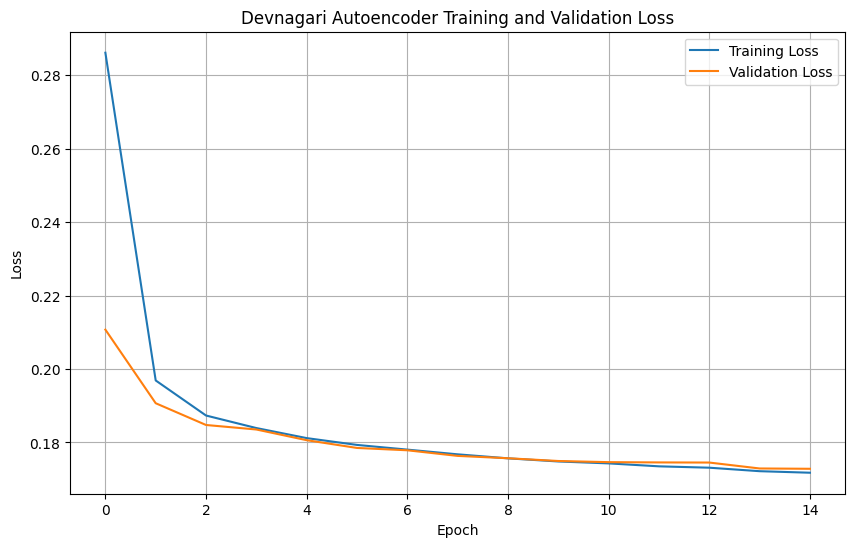

In [15]:


# Rebuild the autoencoder with the corrected architecture
devnagari_autoencoder = build_devnagari_autoencoder()
devnagari_autoencoder.summary() # Optional, but good for verification

history_dev = devnagari_autoencoder.fit(
    x_train_noisy_dev, x_train_dev,
    epochs=15, # Increased epochs for better training
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy_dev, x_test_dev)
)

plt.figure(figsize=(10, 6))
plt.plot(history_dev.history['loss'], label='Training Loss')
plt.plot(history_dev.history['val_loss'], label='Validation Loss')
plt.title('Devnagari Autoencoder Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### 4. Evaluate and Visualize the Results for Devnagari

93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step


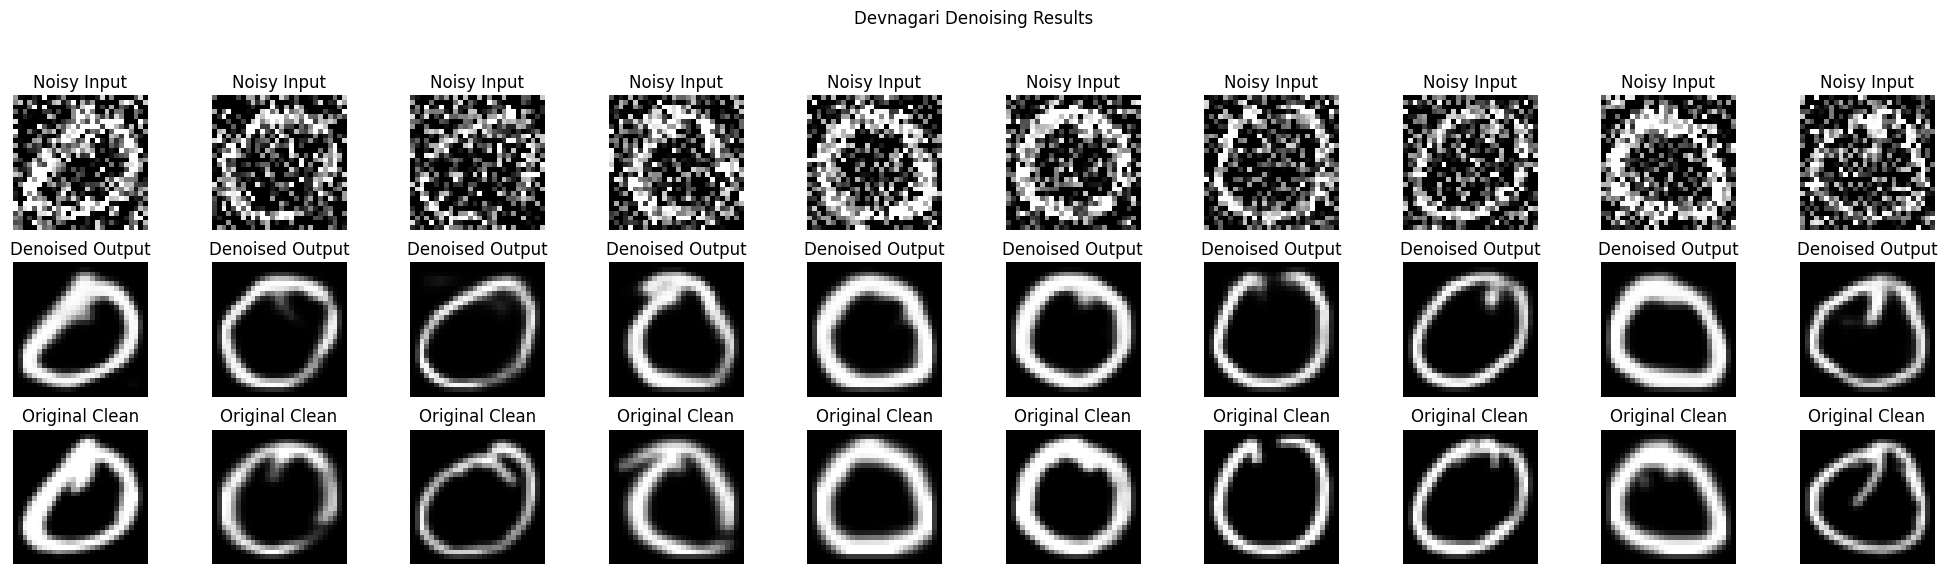

In [16]:
denoised_images_dev = devnagari_autoencoder.predict(x_test_noisy_dev)

def plot_devnagari_images(noisy_images, denoised_images, clean_images, n=10):
  plt.figure(figsize=(20, 6))
  for i in range(n):
    # Plot noisy images
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(noisy_images[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy Input")
    plt.axis('off')

    # Plot denoised images
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
    plt.title("Denoised Output")
    plt.axis('off')

    # Plot clean images
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(clean_images[i].reshape(28, 28), cmap='gray')
    plt.title("Original Clean")
    plt.axis('off')
  plt.suptitle("Devnagari Denoising Results")
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
  plt.show()

# Display the first 10 images from the Devnagari test set
plot_devnagari_images(x_test_noisy_dev, denoised_images_dev, x_test_dev, n=10)